# Testing ocean data on ACCESS-Vis tools

In [1]:
import accessvis
import time
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import intake
import cmocean as cm
import cartopy.crs as ccrs

accessvis.resolution_selection(default=1)

Low-res 2K - fast for testing
Mid-res 4K - good enough for full earth views
High res 8K - better if showing close up at country scale
Ultra-high 16K - max detail but requires a fast GPU with high memory


Dropdown(description='Detail:', options=(('Low-res 2K', 1), ('Mid-res 4K', 2), ('High-res 8K', 3), ('Ultra-hig…


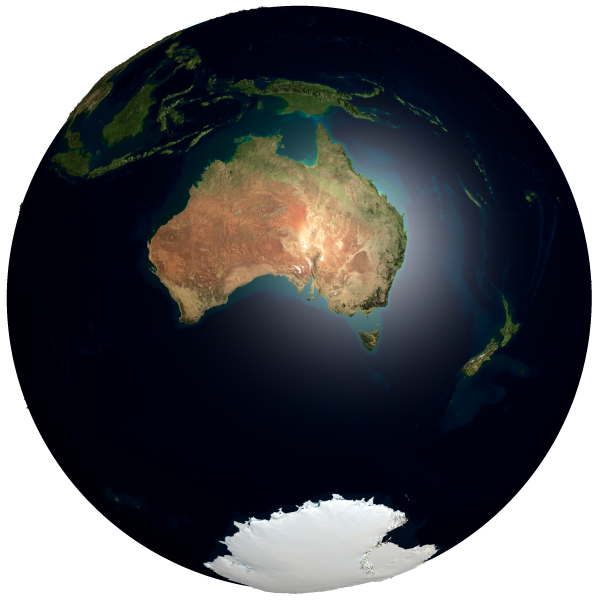

In [7]:
lv = accessvis.plot_earth(texture='bluemarble', background="white", vertical_exaggeration=20)
lv.rotation(-135.0, -35.0, 160.0) #Rotate to Australia
lv.translation(0.0, 0.0, -17)
lv.display(resolution=(600,600))

# Load ocean data to plot on this globe

In [3]:
esm_file='/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-5165c0f8/datastore.json'

In [4]:
COLUMNS_WITH_ITERABLES = [
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units"
]

datastore = intake.open_esm_datastore(
    esm_file,
    columns_with_iterables=COLUMNS_WITH_ITERABLES
)

In [5]:
def available_variables(datastore):
    """Return a pandas dataframe summarising the variables in a datastore"""
    variable_columns = [col for col in datastore.df.columns if "variable" in col]
    return (
        datastore.df[variable_columns]
        .explode(variable_columns)
        .drop_duplicates()
        .set_index("variable")
        .sort_index()
    )

In [6]:
datastore_filtered = datastore.search(realm="ocean",variable="speed")

available_variables(datastore_filtered)

,variable_long_name,variable_standard_name,variable_cell_methods,variable_units
variable,,,,
average_DT,Length of average period,,,days
average_T1,Start time for average period,,,days since 1900-01-01 00:00:00
average_T2,End time for average period,,,days since 1900-01-01 00:00:00
nv,vertex number,,,
speed,Sea Surface Speed,,area:mean yh:mean xh:mean time: mean,m s-1
time,time,,,days since 1900-01-01 00:00:00
time_bnds,time axis boundaries,,,days since 1900-01-01 00:00:00
xh,h point nominal longitude,,,degrees_east
yh,h point nominal latitude,,,degrees_north


In [7]:
speed = datastore.search(variable="speed", frequency="1day").to_dask(
    xarray_combine_by_coords_kwargs = dict( # These kwargs can make things faster
        compat="override",
        data_vars="minimal",
        coords="minimal",
    ),
    xarray_open_kwargs = dict(
        chunks={"yh": -1, "xh": -1}, # Good for spatial operations, but not temporal
        decode_timedelta=True
    )
)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


In [8]:
speed

<xarray.Dataset> Size: 138GB
Dimensions:  (time: 20819, yh: 1152, xh: 1440)
Coordinates:
  * time     (time) datetime64[ns] 167kB 1958-01-01T12:00:00 ... 2014-12-31T1...
  * yh       (yh) float64 9kB -81.58 -81.52 -81.45 -81.39 ... 89.74 89.84 89.95
  * xh       (xh) float64 12kB -279.9 -279.6 -279.4 -279.1 ... 79.38 79.62 79.88
Data variables:
    speed    (time, yh, xh) float32 138GB dask.array<chunksize=(1, 1152, 1440), meta=np.ndarray>
Attributes: (12/15)
    title:                                    ACCESS-OM3
    associated_files:                         areacello: access-om3.mom6.stat...
    grid_type:                                regular
    grid_tile:                                N/A
    intake_esm_vars:                          ['speed']
    intake_esm_attrs:file_id:                 ocean.1day.nv:2.xh:1440.yh:1152
    ...                                       ...
    intake_esm_attrs:variable_standard_name:  ,,,,,,,,
    intake_esm_attrs:variable_cell_methods:   ,,,,area:mean yh:mean xh:mean t...
    intake_esm_attrs:variable_units:          days,days since 1900-01-01 00:0...
    intake_esm_attrs:realm:                   ocean
    intake_esm_attrs:_data_format_:           netcdf
    intake_esm_dataset_key:                   ocean.1day.nv:2.xh:1440.yh:1152

In [9]:
speed_last = speed.isel(time=-1).load()

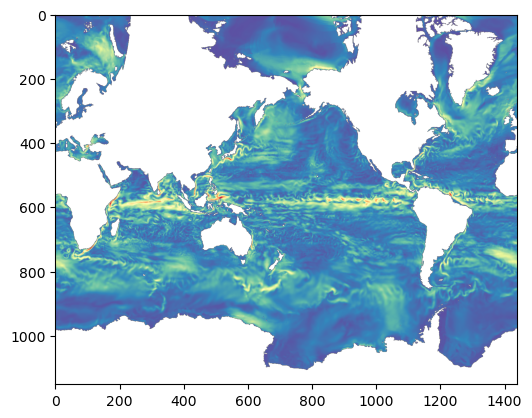

In [10]:
colours = accessvis.array_to_rgba(speed_last['speed'].roll(xh=320), flip=True, colourmap='Spectral_r')
plt.imshow(colours)


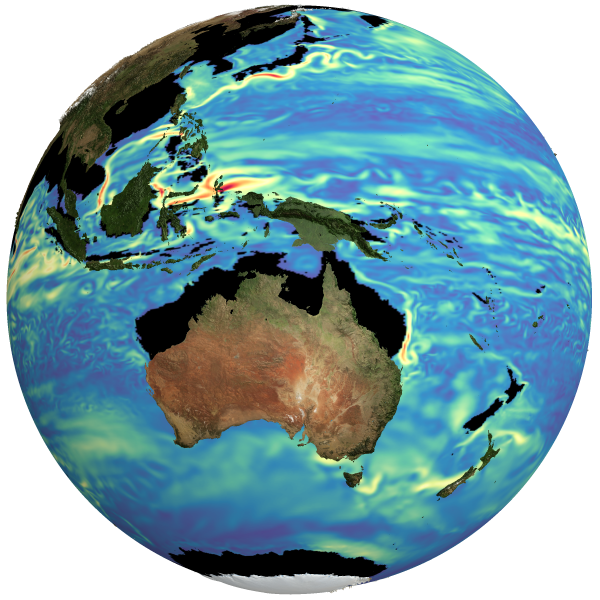

In [11]:
accessvis.update_earth_values(lv, dataMode=1, dataAlpha=1.0, data=colours)
lv.display(resolution=(600,600))

OK, so, this almost works. The issue is that it is assumed that starting position is 0° longitude, it goes from -90° to 90° latitude and the grid spacing is even. I could get around this by:
* Making a plot using cartopy and using that image (clunky); or
* Regrid data (very clunky); or
* Being able to input lat/lon values into the overlay...

Let's try the first of these options, for now.

In [12]:
ds = datastore.search(variable=["geolon", "geolat"],frequency="fx",variable_units="degree").to_dask()
ds=ds.rename({'lonh':'xh','lath':'yh'})

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/source.py:308: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(


In [13]:
ds

<xarray.Dataset> Size: 27MB
Dimensions:  (yh: 1152, xh: 1440)
Coordinates:
  * yh       (yh) float64 9kB -81.58 -81.52 -81.45 -81.39 ... 89.74 89.84 89.95
  * xh       (xh) float64 12kB -279.9 -279.6 -279.4 -279.1 ... 79.38 79.62 79.88
Data variables:
    geolon   (yh, xh) float64 13MB dask.array<chunksize=(1152, 1440), meta=np.ndarray>
    geolat   (yh, xh) float64 13MB dask.array<chunksize=(1152, 1440), meta=np.ndarray>
Attributes: (12/16)
    NumFilesInSet:                            1
    intake_esm_vars:                          ['geolon', 'geolat']
    intake_esm_attrs:filename:                access-om3.mom6.geometry.nc
    intake_esm_attrs:path:                    /g/data/ol01/outputs/access-om3...
    intake_esm_attrs:file_id:                 ocean.fx.lath:1152.latq:1153.lo...
    intake_esm_attrs:frequency:               fx
    ...                                       ...
    intake_esm_attrs:variable_standard_name:  ,,,,,,,,,,,,,,,,,,,,,,
    intake_esm_attrs:variable_cell_methods:   ,,,,,,,,,,,,,,,,,,,,,,
    intake_esm_attrs:variable_units:          m2,m2,meter,m,m,m,m,m,m,m,m,m,m...
    intake_esm_attrs:realm:                   ocean
    intake_esm_attrs:_data_format_:           netcdf
    intake_esm_dataset_key:                   ocean.fx.lath:1152.latq:1153.lo...

In [14]:
speed_plot = speed_last.assign_coords({"geolon": ds.geolon, "geolat": ds.geolat})

In [15]:
speed_plot

<xarray.Dataset> Size: 33MB
Dimensions:  (yh: 1152, xh: 1440)
Coordinates:
  * yh       (yh) float64 9kB -81.58 -81.52 -81.45 -81.39 ... 89.74 89.84 89.95
  * xh       (xh) float64 12kB -279.9 -279.6 -279.4 -279.1 ... 79.38 79.62 79.88
    time     datetime64[ns] 8B 2014-12-31T12:00:00
    geolon   (yh, xh) float64 13MB dask.array<chunksize=(1152, 1440), meta=np.ndarray>
    geolat   (yh, xh) float64 13MB dask.array<chunksize=(1152, 1440), meta=np.ndarray>
Data variables:
    speed    (yh, xh) float32 7MB nan nan nan nan nan ... nan nan nan nan nan
Attributes: (12/15)
    title:                                    ACCESS-OM3
    associated_files:                         areacello: access-om3.mom6.stat...
    grid_type:                                regular
    grid_tile:                                N/A
    intake_esm_vars:                          ['speed']
    intake_esm_attrs:file_id:                 ocean.1day.nv:2.xh:1440.yh:1152
    ...                                       ...
    intake_esm_attrs:variable_standard_name:  ,,,,,,,,
    intake_esm_attrs:variable_cell_methods:   ,,,,area:mean yh:mean xh:mean t...
    intake_esm_attrs:variable_units:          days,days since 1900-01-01 00:0...
    intake_esm_attrs:realm:                   ocean
    intake_esm_attrs:_data_format_:           netcdf
    intake_esm_dataset_key:                   ocean.1day.nv:2.xh:1440.yh:1152

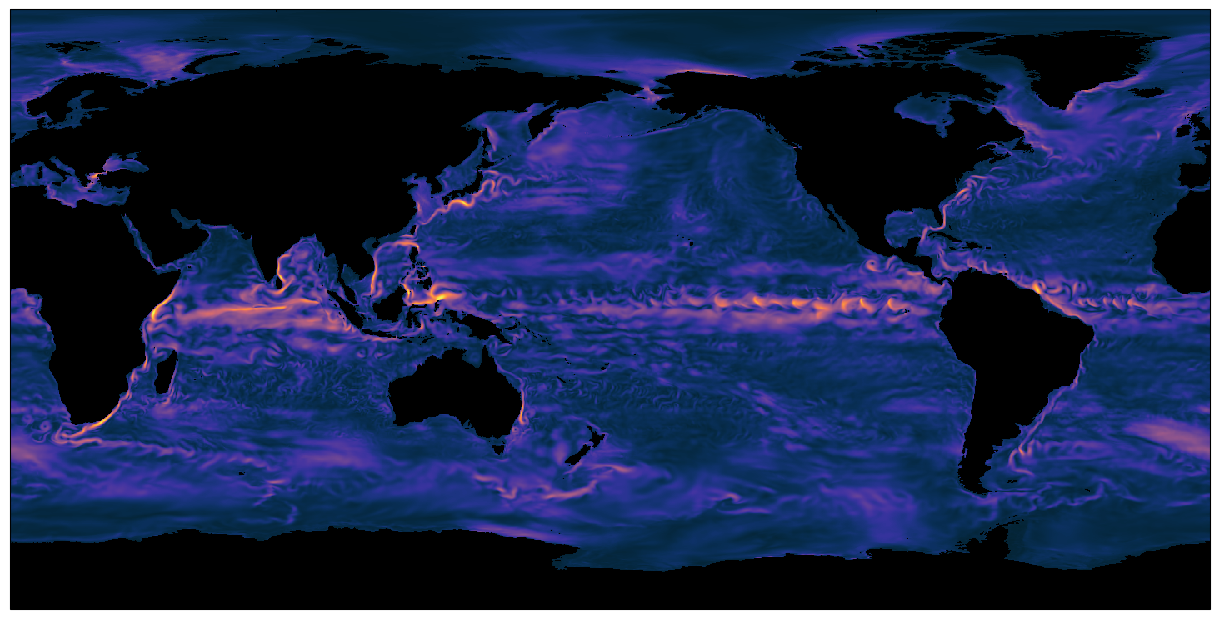

In [16]:
fig = plt.figure(figsize=(12, 6))

ax = plt.axes([0, 0, 1, 1],projection=ccrs.PlateCarree())
ax.set_facecolor('k')

speed_plot['speed'].plot(ax=ax,x="geolon",y="geolat",transform=ccrs.PlateCarree(central_longitude=180),cmap=cm.cm.thermal,add_colorbar=False)
plt.ylim([-90,90])
plt.title('')
plt.savefig('/g/data/x77/amh157/speed.png',dpi=300)

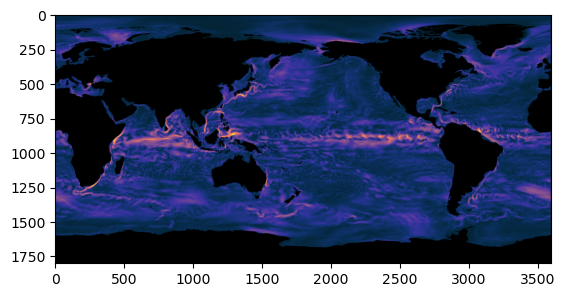

In [17]:
img = Image.open('/g/data/x77/amh157/speed.png')
arr = np.array(img)
plt.imshow(arr)


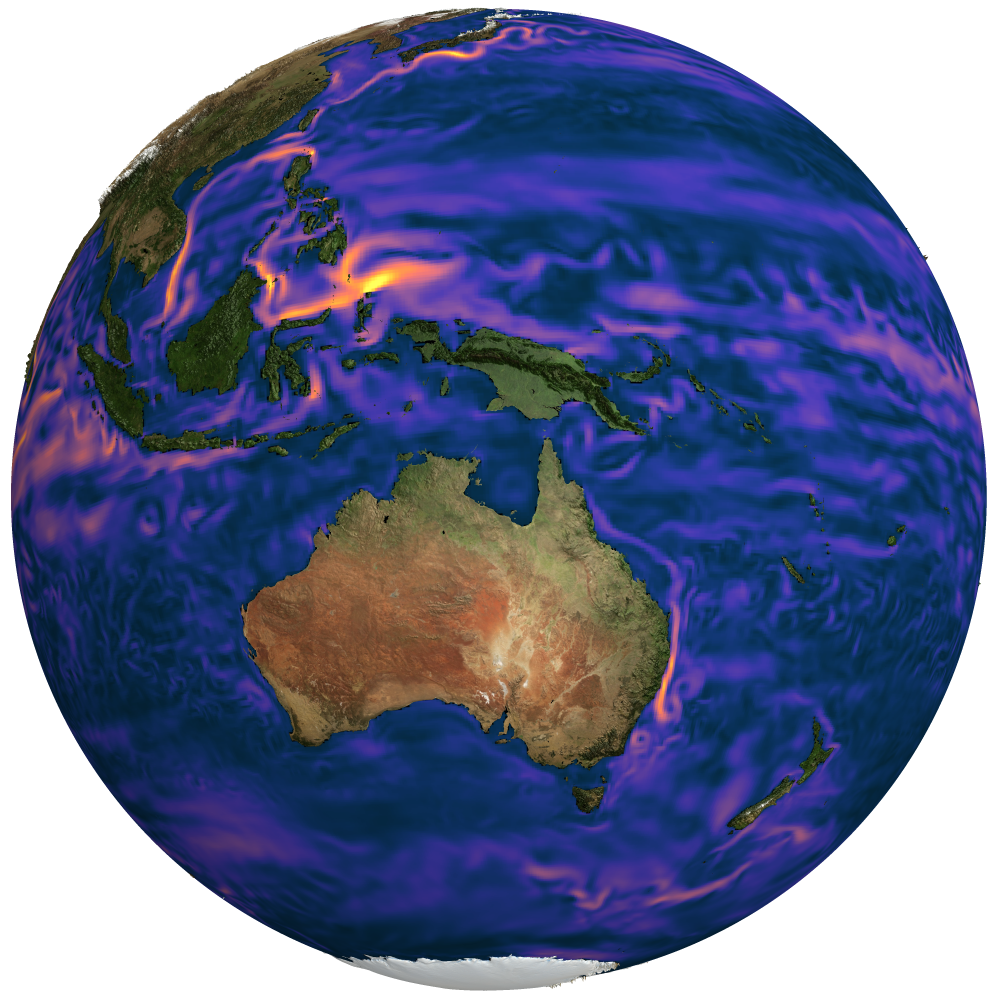

'/g/data/x77/amh157/speed-on-globe.png'

In [20]:
accessvis.update_earth_values(lv, dataMode=1, data=arr)
lv.display(resolution=(1000, 1000))
lv.image(filename='/g/data/x77/amh157/speed-on-globe.png', resolution=(1000, 1000))